<h1><center>Laboratorio 7: Ensamblaje, Optimización de Hiperparámetros e Interpretabilidad 🤖</center></h1>

<center><strong>MDS7202: Laboratorio de Programación Científica para Ciencia de Datos</strong></center>

---

### Cuerpo Docente

- Profesores: Pablo Badilla y Diego Cortez
- Auxiliares: Valentina Rojas y Melanie Peña
- Ayudantes: Javiera Arévalo, Tamara Carrasco y Ignacio Reyes

### Equipo: SUPER IMPORTANTE - notebooks sin nombre no serán revisados

- Nombre de alumno 1: Isadora Madrid

---

### Reglas

- **Grupos de 2 personas**
- Cualquier duda fuera del horario de clases al foro. Mensajes al equipo docente serán respondidos por este medio.
- Prohibido copiar.
- Uso de LLM (Copilot, Claude, Antigravity, Cursor, etc.) restringido a consultas, documentación y corrección de errores.

## Temas a tratar

- Ensamblaje: Bagging (`RandomForest`), Boosting (`XGBoost`, `LightGBM`) y Stacking.
- Optimización de Hiperparámetros con `Optuna` y visualización interactiva con `optuna-dashboard`.
- Interpretabilidad global: `Permutation Feature Importance (PFI)`.
- Interpretabilidad local: `SHAP`.

### Objetivos principales del laboratorio

- Aplicar y comparar métodos de ensamblaje sobre un problema de clasificación de texto.
- Optimizar hiperparámetros de LightGBM usando Optuna y visualizar el proceso con `optuna-dashboard`.
- Interpretar las predicciones del modelo usando PFI y SHAP.

El laboratorio deberá ser desarrollado sin el uso indiscriminado de iteradores nativos de Python (aka "for", "while"). La idea es que aprendan a exprimir al máximo las funciones optimizadas que nos entrega `pandas`.

### Instalamos librerías 😸

In [1]:
import warnings

import matplotlib.pyplot as plt
import nltk
import numpy as np
import optuna
import pandas as pd
import shap
from lightgbm import LGBMClassifier
from nltk import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import PorterStemmer
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.inspection import PartialDependenceDisplay, permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, f1_score
from sklearn.model_selection import StratifiedKFold, cross_val_score, train_test_split  # noqa: F401
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.tree import DecisionTreeClassifier
from optuna.visualization import (
    plot_parallel_coordinate,
    plot_optimization_history,
    plot_param_importances,
)
import plotly.express as px
from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

nltk.download("stopwords", quiet=True)
nltk.download("punkt", quiet=True)
nltk.download("punkt_tab", quiet=True)

RANDOM_STATE = 42
optuna.logging.set_verbosity(optuna.logging.WARNING)

c:\Users\Acer\OneDrive\Escritorio\MDS7202\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# 1. ¿Quién es Bat Cow?

<p align="center">
  <img src="https://i.imgur.com/D9f1RHy.jpg" width="350">
</p>

En vez de estar desarrollando las evaluaciones correspondientes a su curso, su profesor de catedra y su auxiliar discuten acerca la alineación (i.e., si es heroe o villano) del personaje de ficción Bat-Cow.

El cuerpo docente, no logra ponerse de acuerdo si el personaje es bueno, neutral o malo: el auxiliar plantea que Bat-cow posee una siniestra mirada, intrigante pero común característica de los personajes malvados.
Por otra parte, extendiendo las ideas de Rousseau, el profesor plantea que tal como los humanos no nacen malos, no existe motivo por el cual una vaca con superpoderes deba serlo.

Sin embargo, ambos concuerdan que es difícil estimar la alineación solo usando los atributos físicos. Es por esto que les solicitan construir y optimizar un clasificador basado en texto que analice la alineación de cada personaje basado en su historia personal.

Para este laboratorio deben trabajar con los datos `df_comics.csv` y `comics_no_label.csv` subidos a u-cursos.

In [4]:
df_comics = pd.read_csv("df_comics.csv", index_col=0)
df_comics_no_label = pd.read_csv("comics_no_label.csv", index_col=0)
df_comics = df_comics.dropna(subset=["history_text"])
df_comics

,name,real_name,full_name,overall_score,history_text,powers_text,intelligence_score,strength_score,speed_score,durability_score,...,has_flight,has_accelerated_healing,has_weapons_master,has_intelligence,has_reflexes,has_super_speed,has_durability,has_stamina,has_agility,has_super_strength
0,3-D Man,"Delroy Garrett, Jr.","Delroy Garrett, Jr.",6,"Delroy Garrett, Jr. grew up to become a track ...",NaN,85,30,60,60,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0
2,A-Bomb,Richard Milhouse Jones,Richard Milhouse Jones,20,"Richard ""Rick"" Jones was orphaned at a young ...","On rare occasions, and through unusual circu...",80,100,80,100,...,0.0,1.0,0.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0
3,Aa,Aa,NaN,12,Aa is one of the more passive members of the P...,NaN,80,50,55,45,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,Aaron Cash,Aaron Cash,Aaron Cash,5,Aaron Cash is the head of security at Arkham A...,NaN,80,10,25,40,...,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,Aayla Secura,Aayla Secura,NaN,8,ayla Secura was a Rutian Twi'lek Jedi Knight (...,NaN,90,40,45,55,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1445,Zatanna,Zatanna Zatara,Zatanna Zatara,10,Zatanna is the daughter of adventurer John Zat...,Zatanna is genetically talented with her magi...,90,10,25,30,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1446,Zero,DWN-∞: Zero,DWN-∞: Zero,18,Zero was created by the late Dr. Albert Wily ...,NaN,80,100,100,100,...,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1447,Zoom (New 52),Hunter Zolomon,NaN,20,"Hunter Zolomon is better known as Zoom, a spee...",After tricking Barry Allen and Wally West into...,95,50,100,75,...,0.0,1.0,0.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0
1448,Zoom,Hunter Zolomon,Hunter Zolomon,9,Hunter Zolomon had a troubled relationship wi...,"Zoom is able to alter time, to make himself ev...",75,10,100,30,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0


## 1.1 Obtención de Features y Bag of Words

<p align="center">
  <img src="https://media0.giphy.com/media/eIUpSyzwGp0YhAMTKr/200.gif" width="300">
</p>

`bag of words` es un modelo de conteo utilizado en NLP que genera una representación vectorial para cada documento a través del conteo de las palabras que contienen.

<p align="center">
  <img src="https://user.oc-static.com/upload/2020/10/23/16034397439042_surfin%20bird%20bow.png" width="500">
</p>

Para facilitar el conteo transformamos cada documento en un vector mediante **tokenización**:

In [5]:
docs = ["The teacher rocks like a good rock & roll", "the rock is the best actor in the world"]
docs_tokenizados = [word_tokenize(doc) for doc in docs]
docs_tokenizados

[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'],
 ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world']]

Podemos mejorar la tokenización con:

- **Stemming**: transforma palabras a su forma raíz (*running → run*, *rocks → rock*).
- **Eliminación de Stopwords**: elimina palabras muy frecuentes que entorpecen la clasificación (*the*, *is*, *a*, ...).

<p align="center">
  <img src="https://devopedia.org/images/article/218/8583.1569386710.png" width="300">
</p>

In [6]:
stop_words = stopwords.words("english")


class StemmerTokenizer:
    def __init__(self):
        self.ps = PorterStemmer()

    def __call__(self, doc):
        doc_tok = word_tokenize(doc)
        doc_tok = [t for t in doc_tok if t not in stop_words]
        return [self.ps.stem(t) for t in doc_tok]


tokenizador = StemmerTokenizer()

docs = [
    "The teacher rocks like a good rock & roll",
    "the rock is the best actor in the world",
    "New York is a beautiful city",
]

print("Con StemmerTokenizer:")
print([tokenizador(doc) for doc in docs])
print("\nSin preprocesamiento:")
print([word_tokenize(doc) for doc in docs])

Con StemmerTokenizer:
[['the', 'teacher', 'rock', 'like', 'good', 'rock', '&', 'roll'], ['rock', 'best', 'actor', 'world'], ['new', 'york', 'beauti', 'citi']]

Sin preprocesamiento:
[['The', 'teacher', 'rocks', 'like', 'a', 'good', 'rock', '&', 'roll'], ['the', 'rock', 'is', 'the', 'best', 'actor', 'in', 'the', 'world'], ['New', 'York', 'is', 'a', 'beautiful', 'city']]


#### Al Estilo Scikit

Scikit implementa `bag of words` con `CountVectorizer()`. Además soporta **n-gramas**: secuencias contiguas de n palabras que se tratan como un único token. Esto permite capturar contexto local que los unigramas pierden.

| Tipo | n | Tokens de `"nueva york ciudad"` |
|------|---|--------------------------------|
| Unigrama | 1 | `nueva`, `york`, `ciudad` |
| Bigrama | 2 | `nueva york`, `york ciudad` |
| Trigrama | 3 | `nueva york ciudad` |

Con `ngram_range=(1,2)` el vectorizador incluye **unigramas y bigramas** simultáneamente. Los bigramas son especialmente útiles para capturar expresiones compuestas como `bat cow`, `spider man` o `super hero` que pierden su significado si se separan.

El parámetro `max_features` limita el vocabulario a los n tokens más frecuentes, controlando la dimensionalidad de la representación.

In [ ]:
bow = CountVectorizer(tokenizer=StemmerTokenizer(), ngram_range=(1, 2))
df_bow = bow.fit_transform(docs)
pd.DataFrame(df_bow.toarray(), columns=bow.get_feature_names_out())

,&,& roll,actor,actor world,beauti,beauti citi,best,best actor,citi,good,...,rock,rock &,rock best,rock like,roll,teacher,teacher rock,world,york,york beauti
0,1,1,0,0,0,0,0,0,0,1,...,2,1,0,1,1,1,1,0,0,0
1,0,0,1,1,0,0,1,1,0,0,...,1,0,1,0,0,0,0,1,0,0
2,0,0,0,0,1,1,0,0,1,0,...,0,0,0,0,0,0,0,0,1,1


#### Combinando Features: `ColumnTransformer`

Para combinar en un solo paso el preprocesamiento de texto y numérico, usamos `ColumnTransformer`. Este aplica transformadores distintos a subconjuntos de columnas del DataFrame y concatena el resultado en una sola matriz de features lista para entrenar.

<p align="center">
  <img src="https://c.tenor.com/LkQzw7k5DV4AAAAd/anime-hacking.gif" width="300">
</p>

El `preprocessing_transformer` que usaremos a lo largo del lab combina:

- **`CountVectorizer`** con `StemmerTokenizer`, `ngram_range=(1,2)` y `max_features=500` → aplicado sobre la columna `history_text`.
- **`MinMaxScaler`** → aplicado sobre los 6 atributos numéricos de habilidad: `intelligence_score`, `strength_score`, `speed_score`, `durability_score`, `power_score`, `combat_score`.

In [ ]:
preprocessing_transformer = ColumnTransformer(
    transformers=[
        (
            "MinMaxScaler",
            MinMaxScaler(),
            [
                "intelligence_score",
                "strength_score",
                "speed_score",
                "durability_score",
                "power_score",
                "combat_score",
            ],
        ),
        (
            "bow",
            CountVectorizer(
                tokenizer=StemmerTokenizer(),
                max_features=500,
                ngram_range=(1, 2),
            ),
            "history_text",
        ),
    ]
)

## 1.2 Diseño de Baseline y Primer Entrenamiento [1 Punto]

<p align="center">
  <img src="https://pa1.narvii.com/6374/9eaec1b7bf9157334151452a669516f9a78b954c_hq.gif" width="300">
</p>

### 1.2.1 ¿Qué es un Baseline? [0.2 Puntos]

Antes de entrenar modelos complejos, es fundamental establecer un punto de referencia mínimo. Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué es un baseline en Machine Learning?** ¿Para qué sirve establecerlo antes de evaluar modelos más sofisticados?
2. **¿Por qué usamos un `DummyClassifier` como baseline?** ¿Qué implica que un modelo "real" no logre superar su rendimiento?

> 1.- Un baseline en Machine Learning es un modelo base que funciona como punto de referencia inicial. Sirve para comparar si modelos más complejos realmente agregan valor o si solo obtienen un rendimiento similar a una regla básica. Establecerlo antes de entrenar modelos sofisticados permite saber cuál es el desempeño mínimo esperable en el problema.

> 2.- Usamos un DummyClassifier como baseline porque no aprende patrones complejos, sino que predice usando una estrategia simple, como elegir siempre la clase más frecuente. Si un modelo real no logra superar a este baseline que definimos , significa que no está capturando información útil de los datos, por lo tanto, no justifica su complejidad.

---

### 1.2.2 Implementación [0.6 Puntos]

Genere un `Pipeline` con las características de 1.1 y un `DecisionTreeClassifier()` por defecto.

Separe el dataset en entrenamiento/prueba (80/20, estratificado, `random_state=RANDOM_STATE`). Entrene, reporte `classification_report` y compare con un `DummyClassifier(strategy="stratified")`.

**To-do:**
- [ ] Pipeline con preprocesamiento → `DecisionTreeClassifier`.
- [ ] Holdout estratificado 80/20.
- [ ] `classification_report` del baseline.
- [ ] Entrenar `DummyClassifier` y comparar.

In [9]:
#### Código aquí ####

# Columnas usadas en el preprocesamiento definido en 1.1
numeric_features = [
    "intelligence_score",
    "strength_score",
    "speed_score",
    "durability_score",
    "power_score",
    "combat_score",
]

feature_cols = ["history_text"] + numeric_features

# Variable objetivo
target_col = "alignment"

# Si el nombre de la columna objetivo fuera distinto, esto ayuda a detectarlo
if target_col not in df_comics.columns:
    raise ValueError(f"No existe la columna '{target_col}'. Revisa el nombre de la variable objetivo con df_comics.columns")

# Definimos X e y
X = df_comics[feature_cols].copy()
y = df_comics[target_col].copy()

# Tratamiento simple de valores faltantes
X["history_text"] = X["history_text"].fillna("")
X[numeric_features] = X[numeric_features].fillna(X[numeric_features].median())

# Separación entrenamiento/prueba 80/20 estratificada
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=RANDOM_STATE,
)

# Pipeline: preprocesamiento + DecisionTreeClassifier por defecto
tree_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        ("classifier", DecisionTreeClassifier(random_state=RANDOM_STATE)),
    ]
)

# Entrenamiento del árbol
tree_pipeline.fit(X_train, y_train)

# Predicción del árbol
y_pred_tree = tree_pipeline.predict(X_test)

print("=== DecisionTreeClassifier ===")
print(classification_report(y_test, y_pred_tree))

# DummyClassifier como baseline simple
dummy_model = DummyClassifier(
    strategy="stratified",
    random_state=RANDOM_STATE,
)

dummy_model.fit(X_train, y_train)

y_pred_dummy = dummy_model.predict(X_test)

print("=== DummyClassifier strategy='stratified' ===")
print(classification_report(y_test, y_pred_dummy))

# Comparación resumida
comparison = pd.DataFrame(
    {
        "modelo": ["DecisionTreeClassifier", "DummyClassifier"],
        "accuracy": [
            accuracy_score(y_test, y_pred_tree),
            accuracy_score(y_test, y_pred_dummy),
        ],
        "f1_macro": [
            f1_score(y_test, y_pred_tree, average="macro"),
            f1_score(y_test, y_pred_dummy, average="macro"),
        ],
    }
)

comparison

=== DecisionTreeClassifier ===
              precision    recall  f1-score   support

         Bad       0.46      0.43      0.44        86
        Good       0.67      0.64      0.66       148
     Neutral       0.12      0.17      0.14        23

    accuracy                           0.53       257
   macro avg       0.41      0.42      0.41       257
weighted avg       0.55      0.53      0.54       257

=== DummyClassifier strategy='stratified' ===
              precision    recall  f1-score   support

         Bad       0.32      0.34      0.33        86
        Good       0.58      0.56      0.57       148
     Neutral       0.12      0.13      0.12        23

    accuracy                           0.45       257
   macro avg       0.34      0.34      0.34       257
weighted avg       0.46      0.45      0.45       257



,modelo,accuracy,f1_macro
0,DecisionTreeClassifier,0.529183,0.412879
1,DummyClassifier,0.447471,0.342320


### 1.2.3 Pregunta de Cierre [0.2 Puntos]

**Pregunta:** ¿El `DecisionTreeClassifier` supera al `DummyClassifier`? ¿Qué concluyes de esto sobre lo que ha aprendido el modelo? Además responde:

1. ¿Por qué el accuracy puede ser una métrica engañosa en este problema? ¿Qué métrica es más apropiada si las clases están desbalanceadas?
2. ¿Por qué se usa el parámetro `stratify` en el `train_test_split`? ¿Qué problema evitamos al usarlo?
3. ¿Es mejor el clasificador que su versión aleatoria? ¿Podemos avanzar con confianza de que estamos clasificando mejor que si por ejemplo, tiraramos un dado con 3 caras?

> 1.- Sí, el DecisionTreeClassifier supera al DummyClassifier, obtiene mayor accuracy y mayor f1_macro. Esto sugiere que el modelo aprendió ciertos patrones útiles desde el texto y las variables numéricas. Sin embargo, el rendimiento sigue siendo bajo, especialmente para la clase Neutral, por lo que el modelo todavía no clasifica con mucha calidad. El accuracy puede ser engañoso porque las clases están desbalanceadas. En este caso, hay muchas más observaciones Good que Neutral, por lo que un modelo podría verse relativamente bueno solo por acertar la clase mayoritaria. Por eso es más apropiado usar f1_macro, porque evalúa el desempeño de cada clase con el mismo peso.

> 2.- Usamos stratify en train_test_split para mantener proporciones similares de clases en entrenamiento y prueba. Así evitamos que una clase minoritaria quede mal representada. 

> 3.- El árbol es mejor que tirar un dado de 3 caras, pero la mejora es moderada, podemos seguir avanzando aunque todavía hay espacio importante para mejorar el model

---

# 2. Métodos de Ensamblaje [2 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/l0HlHFRbmaZtBRhXG/giphy.gif" width="300">
</p>

Los métodos de ensamblaje combinan múltiples modelos para obtener predicciones más robustas. Exploraremos tres estrategias:

| Estrategia | Idea clave | Ejemplo |
|------------|-----------|---------|
| **Bagging** | Modelos en paralelo sobre subconjuntos aleatorios | Random Forest |
| **Boosting** | Modelos en secuencia, cada uno corrige al anterior | XGBoost, LightGBM |
| **Stacking** | Predicciones de modelos base como input de un meta-modelo | StackingClassifier |

Todos usarán el mismo `preprocessing_transformer` de la sección 1.

## 2.1 Bagging: Random Forest [0.5 Puntos]

### 2.1.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Bagging (Bootstrap Aggregating)**. La descripción debe cubrir los siguientes tres pasos:

1. **Generación de subconjuntos**: ¿Cómo se obtienen los subconjuntos de entrenamiento a partir del dataset original? ¿Se usa todo el dataset en cada uno? ¿Se pueden repetir instancias?
2. **Entrenamiento**: ¿Qué se entrena sobre cada subconjunto? ¿Los modelos se entrenan de forma dependiente o independiente entre sí?
3. **Agregación**: ¿Cómo se combinan las predicciones de todos los modelos para obtener una respuesta final?

> **Respuesta:**
> El Bagging consiste en entrenar varios modelos sobre distintos subconjuntos del dataset original. Estos subconjuntos se generan mediante muestreo con reemplazo, por lo que algunas observaciones pueden repetirse y otras pueden no aparecer en una muestra específica.

> Luego, sobre cada subconjunto se entrena un modelo independiente. En Random Forest, estos modelos son árboles de decisión. Los árboles no se entrenan de manera secuencial ni dependen entre sí, sino que cada uno aprende por separado desde su propia muestra.

> Las predicciones se combinan para obtener una respuesta final. En clasificación, esto suele hacerse mediante votación mayoritaria, en terminos simples, cada árbol vota por una clase y se escoge la clase más frecuente. Esto permite reducir la varianza y obtener predicciones más estables que las de un único árbol.


---

### 2.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Pipeline con `RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)`.
- [ ] Entrenar y reportar `classification_report`.

In [10]:
#### Código aquí ####

rf_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=100,
                random_state=RANDOM_STATE,
            ),
        ),
    ]
)

# Entrenar modelo
rf_pipeline.fit(X_train, y_train)

# Predecir en test
y_pred_rf = rf_pipeline.predict(X_test)

# Reporte de clasificación
print("=== RandomForestClassifier ===")
print(classification_report(y_test, y_pred_rf))

# Comparación con modelos anteriores
comparison_rf = pd.DataFrame(
    {
        "modelo": [
            "DummyClassifier",
            "DecisionTreeClassifier",
            "RandomForestClassifier",
        ],
        "accuracy": [
            accuracy_score(y_test, y_pred_dummy),
            accuracy_score(y_test, y_pred_tree),
            accuracy_score(y_test, y_pred_rf),
        ],
        "f1_macro": [
            f1_score(y_test, y_pred_dummy, average="macro"),
            f1_score(y_test, y_pred_tree, average="macro"),
            f1_score(y_test, y_pred_rf, average="macro"),
        ],
    }
)

comparison_rf

=== RandomForestClassifier ===
              precision    recall  f1-score   support

         Bad       0.63      0.28      0.39        86
        Good       0.63      0.93      0.75       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.63       257
   macro avg       0.42      0.40      0.38       257
weighted avg       0.57      0.63      0.56       257



,modelo,accuracy,f1_macro
0,DummyClassifier,0.447471,0.342320
1,DecisionTreeClassifier,0.529183,0.412879
2,RandomForestClassifier,0.626459,0.378577


### 2.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** ¿El Random Forest mejoró respecto al baseline? Comenta los resultados observados en el `classification_report` y explica a qué se debe la diferencia (o falta de ella), considerando las características del algoritmo que describiste anteriormente.

> **Respuesta:**
 El Random Forest sí mejora respecto al baseline DummyClassifier, especialmente en accuracy, pasa de aproximadamente 0.45 a 0.63. También mejora levemente en f1_macro, pasando de aproximadamente 0.34 a 0.38. Esto indica que el modelo sí está aprendiendo patrones útiles desde las variables de texto y numéricas y no está prediciendo solo de manera aleatoria. Sin embargo, al mirar el classification_report se observa que la mejora no es uniforme para todas las clases. El modelo clasifica bastante bien la clase Good, con recall de 0.93 y f1-score de 0.75, pero tiene problemas importantes con Bad y especialmente con Neutral. Para Neutral, el precision, recall y f1-score son 0.00, lo que significa que el modelo prácticamente no logra identificar correctamente esa clase.

> Esto puede deberse al desbalance de clases, Good tiene muchas más observaciones que Neutral. Como Random Forest combina muchos árboles mediante votación mayoritaria, puede tender a favorecer la clase más frecuente si no se ajusta por desbalance. Por eso el accuracy sube bastante, pero el f1_macro no mejora tanto. Entonces, no podemos decir que el modelo sea completamente satisfactorio, porque su desempeño en la clase Neutral es muy bajo.

## 2.2 Boosting: XGBoost y LightGBM [0.8 Puntos]

### 2.2.1 Descripción del algoritmo [0.3 Puntos]

Describe con tus propias palabras cómo funciona el **Boosting**. Tu descripción debe cubrir los siguientes tres pasos:

1. **Entrenamiento secuencial**: ¿En qué se diferencia el Boosting del Bagging en cuanto al orden en que se entrenan los modelos? ¿Son independientes entre sí?
2. **Corrección de errores**: ¿Cómo sabe cada modelo nuevo en qué instancias debe enfocarse? ¿Qué información del modelo anterior utiliza?
3. **Predicción final**: ¿Cómo se combinan las predicciones de todos los modelos? ¿Es una votación simple o una combinación ponderada?

Además, explica brevemente en qué se diferencian **XGBoost** y **LightGBM** como implementaciones de Boosting, y por qué XGBoost requiere que las etiquetas sean numéricas mientras que LightGBM acepta strings directamente.

> **Respuesta:**
El Boosting es una técnica de ensamblaje que entrena varios modelos de forma secuencial. A diferencia del Bagging, donde los modelos se entrenan en paralelo e independientemente, en Boosting cada nuevo modelo se construye considerando los errores cometidos por los modelos anteriores. Los modelos no son independientes entre sí.

> La idea central es que cada modelo nuevo se enfoque más en las observaciones que fueron difíciles de clasificar correctamente. Para hacerlo, el algoritmo utiliza información de los errores previos, por ejemplo los residuos o pesos asociados a las instancias mal clasificadas. Así, en cada iteración el nuevo modelo intenta corregir parcialmente los errores acumulados por el ensamble anterior.

> La predicción final no se obtiene mediante una votación simple como en Random Forest. En general, Boosting combina las predicciones de todos los modelos de forma ponderada, donde cada modelo aporta una corrección al resultado final.

> XGBoost y LightGBM son implementaciones de Boosting. XGBoost construye árboles  de forma secuencial optimizando una función de pérdida regularizada, siendo muy robusto y flexible. LightGBM también usa boosting, pero está optimizado para ser más rápido y eficiente en memoria, especialmente en datasets grandes, usando estrategias como crecimiento de árboles por hojas.

---

### 2.2.2 Implementación [0.4 Puntos]

**To-do:**
- [ ] Crear `LabelEncoder`, ajustarlo sobre `y_train` y transformar `y_train` e `y_test`.
- [ ] Pipeline con `XGBClassifier(random_state=RANDOM_STATE, eval_metric="mlogloss", verbosity=0)`. Reportar resultados decodificando las predicciones con `le.inverse_transform`.
- [ ] Pipeline con `LGBMClassifier(random_state=RANDOM_STATE, verbose=-1)`. Reportar resultados.

In [11]:
#### Código aquí ####

# 1) LabelEncoder para XGBoost
le = LabelEncoder()

y_train_encoded = le.fit_transform(y_train)
y_test_encoded = le.transform(y_test)

# 2) Pipeline con XGBoost
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        (
            "classifier",
            XGBClassifier(
                random_state=RANDOM_STATE,
                eval_metric="mlogloss",
                verbosity=0,
            ),
        ),
    ]
)

# Entrenar XGBoost con etiquetas numéricas
xgb_pipeline.fit(X_train, y_train_encoded)

# Predecir y decodificar predicciones
y_pred_xgb_encoded = xgb_pipeline.predict(X_test)
y_pred_xgb = le.inverse_transform(y_pred_xgb_encoded)

print("=== XGBClassifier ===")
print(classification_report(y_test, y_pred_xgb))


# 3) Pipeline con LightGBM
lgbm_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        (
            "classifier",
            LGBMClassifier(
                random_state=RANDOM_STATE,
                verbose=-1,
            ),
        ),
    ]
)

# LightGBM puede usar las etiquetas originales tipo string
lgbm_pipeline.fit(X_train, y_train)

# Predecir
y_pred_lgbm = lgbm_pipeline.predict(X_test)

print("=== LGBMClassifier ===")
print(classification_report(y_test, y_pred_lgbm))


# 4) Comparación con modelos anteriores
comparison_boosting = pd.DataFrame(
    {
        "modelo": [
            "DummyClassifier",
            "DecisionTreeClassifier",
            "RandomForestClassifier",
            "XGBClassifier",
            "LGBMClassifier",
        ],
        "accuracy": [
            accuracy_score(y_test, y_pred_dummy),
            accuracy_score(y_test, y_pred_tree),
            accuracy_score(y_test, y_pred_rf),
            accuracy_score(y_test, y_pred_xgb),
            accuracy_score(y_test, y_pred_lgbm),
        ],
        "f1_macro": [
            f1_score(y_test, y_pred_dummy, average="macro"),
            f1_score(y_test, y_pred_tree, average="macro"),
            f1_score(y_test, y_pred_rf, average="macro"),
            f1_score(y_test, y_pred_xgb, average="macro"),
            f1_score(y_test, y_pred_lgbm, average="macro"),
        ],
    }
)

comparison_boosting

=== XGBClassifier ===
              precision    recall  f1-score   support

         Bad       0.52      0.36      0.42        86
        Good       0.65      0.84      0.73       148
     Neutral       0.43      0.13      0.20        23

    accuracy                           0.61       257
   macro avg       0.53      0.44      0.45       257
weighted avg       0.59      0.61      0.58       257

=== LGBMClassifier ===
              precision    recall  f1-score   support

         Bad       0.57      0.55      0.56        86
        Good       0.72      0.84      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.67       257
   macro avg       0.43      0.46      0.45       257
weighted avg       0.61      0.67      0.63       257



,modelo,accuracy,f1_macro
0,DummyClassifier,0.447471,0.342320
1,DecisionTreeClassifier,0.529183,0.412879
2,RandomForestClassifier,0.626459,0.378577
3,XGBClassifier,0.614786,0.452795
4,LGBMClassifier,0.669261,0.445307


### 2.2.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Compara los resultados de XGBoost y LightGBM según el `classification_report`. ¿Cuál tuvo mejor desempeño en F1-Macro? ¿Ambos mejoran respecto al baseline? Considerando las diferencias que describiste en 2.2.1, ¿a qué atribuyes las similitudes o diferencias en rendimiento?

> **Respuesta:**
Según los resultados, XGBoost tuvo un desempeño levemente mejor (0.453) que LightGBM (0.445) en F1-Macro. La diferencia es pequeña, pero XGBoost logra un mejor equilibrio promedio entre las clases.

> Ambos modelos mejoran respecto al baseline DummyClassifier, que tenía un F1-Macro cercano a 0.342. Por lo tanto, tanto XGBoost como LightGBM están aprendiendo patrones útiles desde los datos y no se comportan como una estrategia aleatoria.

> Sin embargo, los resultados muestran diferencias importantes. LightGBM obtiene mayor accuracy general, aproximadamente 0.67, mientras que XGBoost obtiene aproximadamente 0.61. Esto ocurre porque LightGBM clasifica muy bien la clase mayoritaria Good, con recall de 0.84 y f1-score de 0.78. LightGBM no logra clasificar correctamente la clase Neutral, obteniendo f1-score 0.00 en esa categoría.

> XGBoost, en cambio, tiene menor accuracy, pero logra identificar algunos casos de Neutral, alcanzando un f1-score de 0.20 en esa clase. Esto explica por qué su F1-Macro termina siendo ligeramente superior, aunque se equivoca más en términos globales, reparte mejor su desempeño entre las clases.

> Las similitudes se deben a que ambos son métodos de boosting y entrenan modelos secuenciales que intentan corregir errores anteriores. Las diferencias pueden atribuirse a la forma en que cada implementación construye los árboles y optimiza el aprendizaje. Además, el desbalance de clases afecta bastante el rendimiento, especialmente para la clase Neutral, que tiene pocos ejemplos.

## 2.3 Stacking [0.7 Puntos]

### 2.3.1 Descripción del algoritmo [0.2 Puntos]

Describe con tus propias palabras cómo funciona el **Stacking**. Tu descripción debe cubrir los siguientes tres aspectos:

1. **Predicciones como features**: ¿Qué rol cumplen los modelos base? ¿Sobre qué datos generan sus predicciones para ser usadas por el meta-modelo? ¿Por qué se usa validación cruzada interna en lugar de predecir directamente sobre los datos de entrenamiento?
2. **Meta-modelo**: ¿Qué recibe como input el meta-modelo y qué aprende? ¿En qué se diferencia su rol del de los modelos base?
3. **Ventaja sobre selección simple**: ¿Por qué el Stacking puede superar a cualquier modelo base individual? ¿Qué aprovecha de la diversidad entre modelos?

> **Respuesta:**
El Stacking es una técnica de ensamblaje que combina varios modelos base usando sus predicciones como nuevas variables o features para un segundo modelo, llamado meta-modelo. Primero, se entrenan distintos modelos base, por ejemplo un árbol, un Random Forest, un modelo de boosting o una regresión logística. Cada uno aprende patrones distintos del mismo problema. Luego, en vez de escoger solo el mejor modelo individual, se usan las predicciones de esos modelos como entrada para otro modelo. Para generar estas predicciones se usa validación cruzada interna. Esto es importante porque evita que el meta-modelo aprenda a partir de predicciones hechas sobre los mismos datos con los que los modelos base fueron entrenados. Si se predijera directamente sobre el entrenamiento, habría riesgo de sobreajuste.

> El meta-modelo recibe como input las predicciones de los modelos base y aprende cómo combinarlas. Su rol es distinto al de los modelos base, pues estos aprenden desde las variables originales, mientras que el meta-modelo aprende desde la salida de esos modelos, identificando en qué casos conviene confiar más en uno u otro.

> La principal ventaja del Stacking es que puede aprovechar la diversidad entre modelos. Si distintos clasificadores cometen errores diferentes o capturan patrones complementarios, el meta-modelo puede aprender una combinación más efectiva que cualquiera de ellos por separado. Por eso, Stacking puede superar a una selección simple del mejor modelo individual.

---

### 2.3.2 Implementación [0.4 Puntos]

**Restricciones:**
- Mínimo **3 modelos base distintos**.
- Solo clasificadores básicos de scikit-learn: `LogisticRegression`, `MultinomialNB`, `SGDClassifier`, `DecisionTreeClassifier`, etc. **No se permiten modelos de ensamblaje** (`RandomForest`, `XGBoost`, `LightGBM`).
- El meta-modelo es de libre elección. Justifica tu elección.

**To-do:**
- [ ] Definir al menos 3 modelos base (solo clasificadores básicos de scikit-learn).
- [ ] Elegir un meta-modelo.
- [ ] Pipeline con `StackingClassifier(cv=3, n_jobs=-1)`.
- [ ] Reportar `classification_report`.

In [13]:
#### Código aquí ####

# Modelos base permitidos: clasificadores básicos de scikit-learn
base_models = [
    (
        "logistic_regression",
        LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
        ),
    ),
    (
        "multinomial_nb",
        MultinomialNB(),
    ),
    (
        "decision_tree",
        DecisionTreeClassifier(
            random_state=RANDOM_STATE,
        ),
    ),
]

# Meta-modelo:
# Elegi LogisticRegression porque es simple, interpretable y puede aprender
# cómo ponderar las predicciones de los modelos base sin agregar demasiada complejidad.
meta_model = LogisticRegression(
    max_iter=1000,
    random_state=RANDOM_STATE,
)

stacking_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        (
            "classifier",
            StackingClassifier(
                estimators=base_models,
                final_estimator=meta_model,
                cv=3,
                n_jobs=-1,
            ),
        ),
    ]
)

# Entrenar Stacking
stacking_pipeline.fit(X_train, y_train)

# Predecir
y_pred_stacking = stacking_pipeline.predict(X_test)

# Reportar resultados
print("=== StackingClassifier ===")
print(classification_report(y_test, y_pred_stacking))

# Comparación con modelos anteriores
comparison_stacking = pd.DataFrame(
    {
        "modelo": [
            "DummyClassifier",
            "DecisionTreeClassifier",
            "RandomForestClassifier",
            "XGBClassifier",
            "LGBMClassifier",
            "StackingClassifier",
        ],
        "accuracy": [
            accuracy_score(y_test, y_pred_dummy),
            accuracy_score(y_test, y_pred_tree),
            accuracy_score(y_test, y_pred_rf),
            accuracy_score(y_test, y_pred_xgb),
            accuracy_score(y_test, y_pred_lgbm),
            accuracy_score(y_test, y_pred_stacking),
        ],
        "f1_macro": [
            f1_score(y_test, y_pred_dummy, average="macro"),
            f1_score(y_test, y_pred_tree, average="macro"),
            f1_score(y_test, y_pred_rf, average="macro"),
            f1_score(y_test, y_pred_xgb, average="macro"),
            f1_score(y_test, y_pred_lgbm, average="macro"),
            f1_score(y_test, y_pred_stacking, average="macro"),
        ],
    }
)

comparison_stacking

=== StackingClassifier ===
              precision    recall  f1-score   support

         Bad       0.58      0.53      0.56        86
        Good       0.69      0.83      0.75       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.66       257
   macro avg       0.42      0.46      0.44       257
weighted avg       0.59      0.66      0.62       257



,modelo,accuracy,f1_macro
0,DummyClassifier,0.447471,0.342320
1,DecisionTreeClassifier,0.529183,0.412879
2,RandomForestClassifier,0.626459,0.378577
3,XGBClassifier,0.614786,0.452795
4,LGBMClassifier,0.669261,0.445307
5,StackingClassifier,0.657588,0.437392


### 2.3.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Justifica la elección de tus modelos base y meta-modelo: ¿por qué los elegiste y qué aporta cada uno? ¿El Stacking mejoró respecto a los modelos base individuales de las secciones anteriores? ¿A qué atribuyes ese resultado considerando cómo funciona el algoritmo?

> **Respuesta:**
Elegí LogisticRegression, MultinomialNB y DecisionTreeClassifier como modelos base porque son clasificadores básicos de scikit-learn y tienen comportamientos distintos. LogisticRegression funciona bien como modelo lineal para datos de alta dimensión como bag of words. MultinomialNB suele ser útil en problemas de clasificación de texto, porque trabaja bien con conteos de palabras. DecisionTreeClassifier aporta un enfoque no lineal, capaz de capturar reglas e interacciones entre variables que los modelos lineales podrían no detectar.

> Como meta-modelo elegí LogisticRegression porque es simple, estable e interpretable. Su función es aprender cómo combinar las predicciones de los modelos base, ponderando cuándo conviene confiar más en uno u otro, sin agregar demasiada complejidad al ensamble.

> Según los resultados, el Stacking mejora claramente respecto al baseline DummyClassifier, obtiene un accuracy cercano a 0.66 y un f1_macro cercano a 0.44, mientras que el DummyClassifier tenía accuracy cercano a 0.45 y f1_macro cercano a 0.34. Esto muestra que el ensamble sí aprende patrones útiles.

> Sin embargo, el Stacking no supera a todos los modelos anteriores. Su accuracy es alto, similar al de LightGBM, pero su f1_macro queda por debajo de XGBoost, que fue el mejor en esa métrica. Además, el Stacking sigue fallando completamente en la clase Neutral, con precision, recall y f1-score de 0.00.

> Esto puede atribuirse al desbalance de clases y a que los modelos base probablemente también tienen dificultades para reconocer la clase Neutral. Como el meta-modelo aprende a partir de las predicciones de esos modelos base, si ninguno entrega algo bueno para Neutral, el Stacking tampoco logra corregirlo.

---

# 3. Optimización de Hiperparámetros con Optuna [1.5 Puntos]

<p align="center">
  <img src="https://media.giphy.com/media/3oKIPEqDGUULpEU0aQ/giphy.gif" width="300">
</p>

Hasta ahora hemos usado hiperparámetros por defecto. En esta sección optimizaremos **LightGBM** con **Optuna**, una librería de optimización bayesiana más eficiente que `GridSearchCV` porque:

- **Samplers inteligentes (TPE)**: usa el historial de trials para proponer mejores valores.
- **Pruning**: abandona trials poco prometedores antes de completarlos.
- **Visualizaciones interactivas**: analiza el espacio de hiperparámetros con `optuna-dashboard`.

Los resultados del estudio se persistirán en una base de datos SQLite, lo que permite explorarlos en tiempo real con el dashboard.

### 3.1 Descripción: Hiperparámetros y Optimización [0.2 Puntos]

Antes de implementar la optimización, reflexiona sobre los siguientes conceptos:

1. **¿Qué son los hiperparámetros?** ¿En qué se diferencian de los parámetros que el modelo aprende durante el entrenamiento?
2. **¿Por qué es importante optimizarlos?** ¿Qué consecuencias puede tener usar hiperparámetros por defecto?
3. **¿Qué es `GridSearchCV`?** Describe cómo funciona su mecanismo de búsqueda y cuál es su principal limitación cuando el espacio de hiperparámetros es grande.
4. **¿Por qué se evalúa cada trial con validación cruzada en lugar de usar directamente el conjunto de test?** ¿Qué problema introduce usar el test para seleccionar hiperparámetros? ¿Cómo podríamos reemplazar la CV por un conjunto de validación separado, y cuáles serían las ventajas y desventajas de ese enfoque?
5. **¿Cómo mejoran los samplers inteligentes la limitación de `GridSearchCV`?** ¿Por qué un sampler como TPE puede ser más eficiente que una búsqueda exhaustiva?

> **Respuesta:**
Los hiperparámetros son configuraciones del modelo que se definen antes del entrenamiento. A diferencia de los parámetros de los que el modelo aprende, los hiperparámetros controlan cómo aprende el modelo. Por ejemplo, en LightGBM algunos hiperparámetros son el número de árboles, la profundidad máxima, el learning rate o el número de hojas.

> Es importante optimizarlos porque los valores por defecto no necesariamente son los mejores para nuestro problema. Si usamos hiperparámetros inadecuados, el modelo puede quedar muy simple y subajustar, o demasiado complejo y sobreajustar. En ambos casos, el rendimiento en datos nuevo puede ser peor.

> GridSearchCV es una técnica de búsqueda exhaustiva. Se define una grilla de valores posibles para cada hiperparámetro y el algoritmo prueba todas las combinaciones. Luego evalúa cada una, normalmente usando validación cruzada, y selecciona la mejor. Su principal limitación es que se vuelve muy costoso cuando hay muchos hiperparámetros o muchos valores posibles, porque el número de combinaciones crece rápidamente.

> Cada trial se evalúa con validación cruzada para estimar mejor cómo se comportaría el modelo en datos no vistos sin usar el conjunto de test. No debemos usar el test para seleccionar hiperparámetros, porque el modelo terminaría ajustándose indirectamente a ese conjunto y la evaluación final dejaría de ser una medición honesta de generalización. Una alternativa a la validación cruzada es separar un conjunto de validación desde el training set. Esto es más rápido porque se entrena menos veces, pero puede ser menos estable, ya que el resultado depende mucho de una única partición. La validación cruzada es más costosa, pero entrega una estimación más robusta.

> Los samplers inteligentes, como TPE en Optuna, mejoran la búsqueda porque no prueban combinaciones de forma ciega o exhaustiva. Usan la información de trials anteriores para proponer configuraciones más favorables. Por eso pueden encontrar buenos hiperparámetros con menos evaluaciones que GridSearchCV, especialmente cuando el espacio de búsqueda es grande.

### 3.2 Definición del Espacio de Búsqueda y Función Objetivo [0.5 Puntos]

La función `objective(trial)` recibe un trial de Optuna, define los hiperparámetros a probar y devuelve la métrica a optimizar (F1-Macro).

| Hiperparámetro | Tipo | Rango | Descripción |
|----------------|------|-------|-------------|
| `num_leaves` | `suggest_int` | [20, 200] | Número máximo de hojas por árbol; controla la complejidad del modelo. |
| `learning_rate` | `suggest_float` (log) | [1e-3, 0.3] | Tasa de aprendizaje; cuánto contribuye cada árbol a la predicción final. |
| `max_depth` | `suggest_int` | [3, 12] | Profundidad máxima de cada árbol; limita la capacidad de memorización. |
| `min_child_samples` | `suggest_int` | [5, 100] | Mínimo de muestras requeridas en una hoja; regulariza contra sobreajuste. |
| `subsample` | `suggest_float` | [0.5, 1.0] | Fracción de filas muestreadas aleatoriamente para entrenar cada árbol. |
| `colsample_bytree` | `suggest_float` | [0.5, 1.0] | Fracción de features muestreadas aleatoriamente para cada árbol. |
| `reg_alpha` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L1 sobre los pesos de las hojas. |
| `reg_lambda` | `suggest_float` (log) | [1e-8, 10.0] | Regularización L2 sobre los pesos de las hojas. |

**To-do:**
- [ ] Implementar `objective(trial)` con el espacio de búsqueda indicado.
- [ ] Usar `StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_STATE)`.
- [ ] Retornar la media del F1-Macro sobre los 3 folds.

In [14]:
#### Código aquí ####
def objective(trial):
    params = {
        "num_leaves": trial.suggest_int("num_leaves", 20, 200),
        "learning_rate": trial.suggest_float("learning_rate", 1e-3, 0.3, log=True),
        "max_depth": trial.suggest_int("max_depth", 3, 12),
        "min_child_samples": trial.suggest_int("min_child_samples", 5, 100),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "reg_alpha": trial.suggest_float("reg_alpha", 1e-8, 10.0, log=True),
        "reg_lambda": trial.suggest_float("reg_lambda", 1e-8, 10.0, log=True),
    }

    pipe = Pipeline(
        steps=[
            ("preprocessing", preprocessing_transformer),
            (
                "classifier",
                LGBMClassifier(
                    **params,
                    random_state=RANDOM_STATE,
                    verbose=-1,
                ),
            ),
        ]
    )

    cv = StratifiedKFold(
        n_splits=3,
        shuffle=True,
        random_state=RANDOM_STATE,
    )

    scores = cross_val_score(
        pipe,
        X_train,
        y_train,
        cv=cv,
        scoring="f1_macro",
    )

    return scores.mean()

### 3.3 Ejecución del Estudio de Optimización [0.4 Puntos]

Crea el estudio Optuna con 50 trials usando `TPESampler`. El estudio se guarda en el storage SQLite configurado anteriormente para poder explorarlo con `optuna-dashboard`.

**To-do:**
- [ ] Crear el estudio con `direction="maximize"`, `TPESampler(seed=RANDOM_STATE)` y el `storage` configurado.
- [ ] Ejecutar `study.optimize` con `n_trials=50` y `show_progress_bar=True`
- [ ] Imprimir el mejor valor y los mejores hiperparámetros.

In [15]:
storage = optuna.storages.RDBStorage("sqlite:///optuna_lab7.db")
study = optuna.create_study(
    direction="maximize",
    study_name="lgbm-comics",
    sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE),
    storage=storage,
    load_if_exists=True,
)

study.optimize(objective, n_trials=50, show_progress_bar=True)

print(f"Mejor F1-Macro: {study.best_value:.4f}")
print("\nMejores hiperparámetros:")
for k, v in study.best_params.items():
    print(f"  {k}: {v}")

Best trial: 20. Best value: 0.452446: 100%|██████████| 50/50 [47:08<00:00, 56.56s/it]

Mejor F1-Macro: 0.4524

Mejores hiperparámetros:
  num_leaves: 177
  learning_rate: 0.06109044652847312
  max_depth: 8
  min_child_samples: 25
  subsample: 0.9956385980717997
  colsample_bytree: 0.7586564720765597
  reg_alpha: 1.2042317147670628e-07
  reg_lambda: 0.2041475808495035


### 3.4 Visualizaciones de Optuna [0.2 Puntos]

Optuna provee visualizaciones interactivas para analizar el proceso de optimización.

**To-do:**
- [ ] Graficar el historial de optimización (`plot_optimization_history`).
- [ ] Graficar la importancia de hiperparámetros (`plot_param_importances`).
- [ ] Graficar una visualización del comportamiento de los hiperparámetros (`plot_parallel_coordinate`)

In [ ]:
#### Código aquí ####
import plotly.io as pio

pio.renderers.default = "browser"

fig_history = plot_optimization_history(study)
fig_history.show()

fig_importance = plot_param_importances(study)
fig_importance.show()

fig_parallel = plot_parallel_coordinate(study)
fig_parallel.show()

### 3.5 Comparar Modelo Base con Mejores Hiperparámetros [0.1 Puntos]

**To-do:**
- [ ] Reentrenar un pipeline `pipe_lgbm_opt` con `study.best_params`.
- [ ] Comparar F1-Macro entre `pipe_lgbm` (defaults) y `pipe_lgbm_opt` (optimizado).

In [19]:
#### Código aquí ####

# Modelo LightGBM base con hiperparámetros por defecto
pipe_lgbm = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        (
            "classifier",
            LGBMClassifier(
                random_state=RANDOM_STATE,
                verbose=-1,
            ),
        ),
    ]
)

pipe_lgbm.fit(X_train, y_train)
y_pred_lgbm_base = pipe_lgbm.predict(X_test)

f1_lgbm_base = f1_score(
    y_test,
    y_pred_lgbm_base,
    average="macro",
)


# Modelo LightGBM optimizado con los mejores hiperparámetros de Optuna
pipe_lgbm_opt = Pipeline(
    steps=[
        ("preprocessing", preprocessing_transformer),
        (
            "classifier",
            LGBMClassifier(
                **study.best_params,
                random_state=RANDOM_STATE,
                verbose=-1,
            ),
        ),
    ]
)

pipe_lgbm_opt.fit(X_train, y_train)
y_pred_lgbm_opt = pipe_lgbm_opt.predict(X_test)

f1_lgbm_opt = f1_score(
    y_test,
    y_pred_lgbm_opt,
    average="macro",
)


# Comparación final
comparacion_lgbm = pd.DataFrame(
    {
        "modelo": [
            "LightGBM base",
            "LightGBM optimizado",
        ],
        "f1_macro": [
            f1_lgbm_base,
            f1_lgbm_opt,
        ],
        "accuracy": [
            accuracy_score(y_test, y_pred_lgbm_base),
            accuracy_score(y_test, y_pred_lgbm_opt),
        ],
    }
)

print("=== LightGBM base ===")
print(classification_report(y_test, y_pred_lgbm_base))

print("=== LightGBM optimizado ===")
print(classification_report(y_test, y_pred_lgbm_opt))

comparacion_lgbm

=== LightGBM base ===
              precision    recall  f1-score   support

         Bad       0.57      0.55      0.56        86
        Good       0.72      0.84      0.78       148
     Neutral       0.00      0.00      0.00        23

    accuracy                           0.67       257
   macro avg       0.43      0.46      0.45       257
weighted avg       0.61      0.67      0.63       257

=== LightGBM optimizado ===
              precision    recall  f1-score   support

         Bad       0.59      0.53      0.56        86
        Good       0.71      0.85      0.78       148
     Neutral       0.50      0.04      0.08        23

    accuracy                           0.67       257
   macro avg       0.60      0.48      0.47       257
weighted avg       0.65      0.67      0.64       257



,modelo,f1_macro,accuracy
0,LightGBM base,0.445307,0.669261
1,LightGBM optimizado,0.472120,0.673152


### 3.6 Preguntas de reflexión [0.1 Puntos]

1. Según `plot_param_importances`, ¿qué hiperparámetro tuvo más impacto? ¿Tiene sentido dado tu conocimiento sobre algoritmos de Boosting?
2. ¿Qué información adicional te entregaron los gráficos de optuna comparado con solo mirar los logs de texto del estudio? ¿Qué pasa si en el gráfico interactivo `plot_parallel_coordinate` seleccionas con el mouse el rango específico con mejores resultados, hay patrones interesantes? - Hint: hace drag con el puntero sobre la dimensión de _Objective Value_ para seleccionar las mejores observaciones.

> Según plot_param_importances, el hiperparámetro con mayor impacto fue learning_rate con una importancia cercana a 0.82. Esto tiene sentido en modelos de Boosting, porque learning_rate controla cuánto aporta cada árbol nuevo a la predicción final. Si es muy alto, el modelo puede sobreajustar o volverse inestable, si es muy bajo, puede necesitar muchos más árboles para aprender bien. Por eso es normal que sea uno de los parámetros más relevantes.

> Dado los gráficos de Optuna, el historial de optimización permite ver cómo fue mejorando el mejor F1-Macro a lo largo de los trials. En este caso, el mejor valor apareció alrededor del trial 20 y luego no mejoró mucho más, lo que sugiere que Optuna encontró relativamente temprano una buena zona del espacio de búsqueda.

> El gráfico de importancia de hiperparámetros permite identificar qué variables conviene ajustar con más cuidado en futuras búsquedas. En este caso, learning_rate parece ser el parámetro más sensible.

> El gráfico de coordenadas paralelas permite ver combinaciones completas de hiperparámetros, no solo valores individuales. Al seleccionar con el cursor los trials con mejor Objective Value, se pueden observar patrones interesantes: los mejores resultados parecen concentrarse en learning_rate moderado, cercano a 0.06, max_depth intermedio-alto, min_child_samples relativamente bajo o medio, subsample alto y colsample_bytree medio-alto. Esto ayuda a entender no solo qué parámetro importa, sino también qué rangos de valores parecen funcionar mejor en conjunto.

> Además, al comparar el modelo base con el optimizado, se observa que LightGBM optimizado mejora el F1-Macro desde aproximadamente 0.445 a 0.472. La mejora no es enorme, pero sí relevante, porque el modelo optimizado comienza a reconocer algunos casos de la clase Neutral, que antes tenía f1-score igual a 0.00. Esto confirma que la optimización de hiperparámetros permitió mejorar el balance entre clases, aunque todavía queda espacio para mejorar el desempeño en la clase minoritaria.

# 4. Interpretabilidad [1 Punto]

<p align="center">
  <img src="https://media.giphy.com/media/xT9IgzoKnwFNmISR8I/giphy.gif" width="300">
</p>

En esta sección interpretaremos las predicciones de LightGBM. Para obtener interpretaciones claras y directas, entrenaremos un **modelo auxiliar de LGBM usando únicamente los 6 atributos numéricos** (scores de habilidades), sin incluir features de texto.

Esto nos permite:
- Aplicar PFI y SHAP sin complicaciones de alta dimensionalidad.
- Obtener explicaciones semánticamente significativas (fuerza, inteligencia, velocidad...).

> **Nota:** En esta sección entrenaremos un modelo auxiliar para interpretabilidad con menos atributos. Usaremos un modelo entrenado desde 0, no el mejor seleccionado anteriormente.

In [21]:
NUMERICAL_FEATURES = [
    "intelligence_score",
    "strength_score",
    "speed_score",
    "durability_score",
    "power_score",
    "combat_score",
]

X_train_num = X_train[NUMERICAL_FEATURES]
X_test_num = X_test[NUMERICAL_FEATURES]

# Reentrenar LGBM con los mejores hiperparámetros, solo sobre scores numéricos
lgbm_interp = LGBMClassifier(
    **study.best_params,
    random_state=RANDOM_STATE,
    verbose=-1,
)

lgbm_interp.fit(X_train_num, y_train)

y_pred_interp = lgbm_interp.predict(X_test_num)

print("=== Modelo auxiliar LightGBM solo con atributos numéricos ===")
print(classification_report(y_test, y_pred_interp))

f1_interp = f1_score(y_test, y_pred_interp, average="macro")
accuracy_interp = accuracy_score(y_test, y_pred_interp)

pd.DataFrame(
    {
        "modelo": ["LGBM interpretabilidad"],
        "accuracy": [accuracy_interp],
        "f1_macro": [f1_interp],
    }
)

=== Modelo auxiliar LightGBM solo con atributos numéricos ===
              precision    recall  f1-score   support

         Bad       0.36      0.23      0.28        86
        Good       0.59      0.77      0.67       148
     Neutral       0.10      0.04      0.06        23

    accuracy                           0.53       257
   macro avg       0.35      0.35      0.34       257
weighted avg       0.47      0.53      0.49       257



,modelo,accuracy,f1_macro
0,LGBM interpretabilidad,0.525292,0.338294


## 4.1 Permutation Feature Importance (PFI) [0.4 Puntos]

### 4.1.1 Descripción [0.1 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Cómo funciona la Permutation Feature Importance?** ¿Qué se permuta exactamente y cómo se mide el impacto en el rendimiento del modelo?
2. **¿Por qué PFI es preferible a la importancia nativa de los árboles de decisión?** ¿Qué sesgo tiene la importancia nativa que PFI evita?

> **Respuesta:**
La Permutation Feature Importance mide qué tan importante es una variable observando cuánto empeora el rendimiento del modelo cuando se rompe la relación entre esa variable y la variable objetivo. Para hacerlo, se toma una feature específica y se permutan aleatoriamente sus valores entre las observaciones, manteniendo el resto de las columnas igual. Si al permutar una variable el rendimiento del modelo cae mucho, significa que esa variable era importante para las predicciones. En cambio, si el rendimiento casi no cambia, entonces el modelo probablemente no dependía mucho de esa feature.

> PFI es preferible a la importancia nativa de árboles en varios casos porque evalúa el impacto de cada variable directamente sobre una métrica de desempeño, por ejemplo F1-Macro, accuracy u otra. En cambio, la importancia nativa de árboles suele basarse en criterios internos del modelo, como la reducción de impureza, y puede estar sesgada hacia variables con muchos posibles puntos de corte o hacia variables continuas. Por eso, PFI entrega una interpretación más relacionada con el rendimiento real del modelo.

---

### 4.1.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Calcular `permutation_importance` con `n_repeats=30` y `scoring="f1_macro"`.
- [ ] Graficar un boxplot horizontal con plotly (`px.bar` con `orientation='h'`) con la importancia y varianza de cada feature.

In [22]:
#### Código aquí ####

# Calcular Permutation Feature Importance sobre el conjunto de test
pfi_result = permutation_importance(
    lgbm_interp,
    X_test_num,
    y_test,
    n_repeats=30,
    random_state=RANDOM_STATE,
    scoring="f1_macro",
)

# Crear DataFrame con importancia media y variabilidad
pfi_df = (
    pd.DataFrame(
        {
            "feature": NUMERICAL_FEATURES,
            "importance_mean": pfi_result.importances_mean,
            "importance_std": pfi_result.importances_std,
            "importance_var": pfi_result.importances.var(axis=1),
        }
    )
    .sort_values("importance_mean", ascending=True)
)

pfi_df

,feature,importance_mean,importance_std,importance_var
2,speed_score,-0.018917,0.015922,0.000253
5,combat_score,-0.015234,0.013680,0.000187
4,power_score,-0.011366,0.023685,0.000561
3,durability_score,-0.000127,0.018784,0.000353
1,strength_score,0.006588,0.020994,0.000441
0,intelligence_score,0.026822,0.019807,0.000392


In [23]:
### Graficar ###
fig_pfi = px.bar(
    pfi_df,
    x="importance_mean",
    y="feature",
    error_x="importance_std",
    orientation="h",
    title="Permutation Feature Importance - LightGBM auxiliar",
    labels={
        "importance_mean": "Disminución promedio en F1-Macro",
        "feature": "Feature",
        "importance_std": "Desviación estándar",
    },
)

fig_pfi.show()

### 4.1.3 Pregunta de Cierre [0.1 Puntos]

**Pregunta:** Según el gráfico de PFI, ¿qué feature tuvo mayor importancia? ¿Tiene sentido intuitivo dado el contexto del problema (clasificar la alineación de personajes de cómics)? ¿Hay alguna feature cuya importancia te sorprenda?

> **Respuesta:**
 Según el gráfico de Permutation Feature Importance, la feature con mayor importancia fue intelligence_score. Esto significa que, al permutar aleatoriamente esta variable, el F1-Macro del modelo cae más que con el resto de las variables, por lo que el modelo depende bastante de ella para clasificar la alineación de los personajes. Esto tiene sentido intuitivo en el contexto del problema, porque la inteligencia puede estar relacionada con el tipo de personaje: villanos, héroes y personajes neutrales pueden diferenciarse no solo por su fuerza física, sino también por su estrategia, planificación o forma de actuar.

> Me sorprende que variables como speed_score, combat_score y power_score tengan importancia negativa. Esto indica que, al permutarlas, el rendimiento no empeora e incluso puede mejorar levemente. Una posible explicación es que esas variables agregan ruido al modelo o que su información no es muy útil para clasificar la alineación. También puede ocurrir porque están correlacionadas con otras variables o porque el modelo auxiliar, al usar solo seis atributos numéricos, tiene un rendimiento limitado.

## 4.2 SHAP (SHapley Additive exPlanations) [0.6 Puntos]

### 4.2.1 Descripción [0.2 Puntos]

Responde las siguientes preguntas con tus propias palabras:

1. **¿Qué miden los SHAP values?** ¿En qué se diferencian de una medida de importancia global como PFI?
2. **¿Qué representa el `base_value` en un `waterfall_plot` de SHAP?** ¿Por qué es el punto de partida para interpretar una predicción individual?
3. **¿Por qué usar `TreeExplainer` para modelos basados en árboles?** ¿Qué ventaja ofrece respecto a un explainer genérico?

> **Respuesta:**
 Los SHAP values miden cuánto aporta cada feature a una predicción específica del modelo, explican una predicción individual indicando qué variables empujan la predicción hacia una clase u otra, y con qué magnitud. A diferencia de PFI, que es una medida global de importancia basada en cuánto cae el rendimiento al permutar una variable.

> El base_value en un waterfall_plot representa el punto de partida de la predicción antes de considerar las características del individuo. Puede entenderse como la predicción promedio o esperada del modelo. Desde ese valor inicial, cada feature suma o resta según su SHAP value, hasta llegar al valor final predicho para esa observación. Por eso es clave para interpretar una predicción individual, muestra desde dónde parte el modelo y cómo cada variable modifica esa predicción.

> Usamos TreeExplainer porque el modelo auxiliar es un modelo basado en árboles, en este caso LightGBM. TreeExplainer aprovecha directamente la estructura interna de los árboles para calcular explicaciones de forma más eficiente y adecuada que un explainer genérico. Un explainer genérico tendría que aproximar los efectos probando muchas perturbaciones de los datos, lo que suele ser más lento y menos preciso para modelos de árboles.

---

### 4.2.2 Implementación [0.2 Puntos]

**To-do:**
- [ ] Crear un `shap.TreeExplainer(lgbm_interp)` y calcular `shap_values` sobre `X_test_num`.
- [ ] `summary_plot` para ver importancia global y dirección del efecto (para la clase "Good").
- [ ] `waterfall_plot` para la predicción de una instancia cualquiera de `X_test_num`.

In [24]:
#### Código aquí ####

# Crear TreeExplainer para el modelo LightGBM auxiliar
explainer = shap.TreeExplainer(lgbm_interp)

# Calcular SHAP values sobre el conjunto de test numérico
shap_exp = explainer(X_test_num)

# Identificar índice de la clase "Good"
class_names = list(lgbm_interp.classes_)
good_idx = class_names.index("Good")

print("Clases del modelo:", class_names)
print("Índice de la clase Good:", good_idx)

Clases del modelo: ['Bad', 'Good', 'Neutral']
Índice de la clase Good: 1


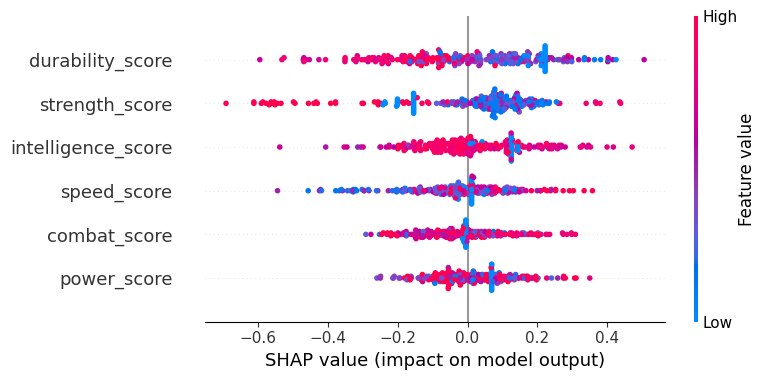

In [25]:
### Summary_plot ###
# Extraer SHAP values para la clase "Good"
if len(shap_exp.values.shape) == 3:
    shap_values_good = shap_exp.values[:, :, good_idx]
else:
    shap_values_good = shap_exp.values

# Summary plot: importancia global y dirección del efecto para la clase Good
shap.summary_plot(
    shap_values_good,
    X_test_num,
    feature_names=NUMERICAL_FEATURES,
    show=True,
)

Instancia analizada:


,intelligence_score,strength_score,speed_score,durability_score,power_score,combat_score
1303,85,10,25,70,60,60


Clase real: Bad
Clase predicha: Bad


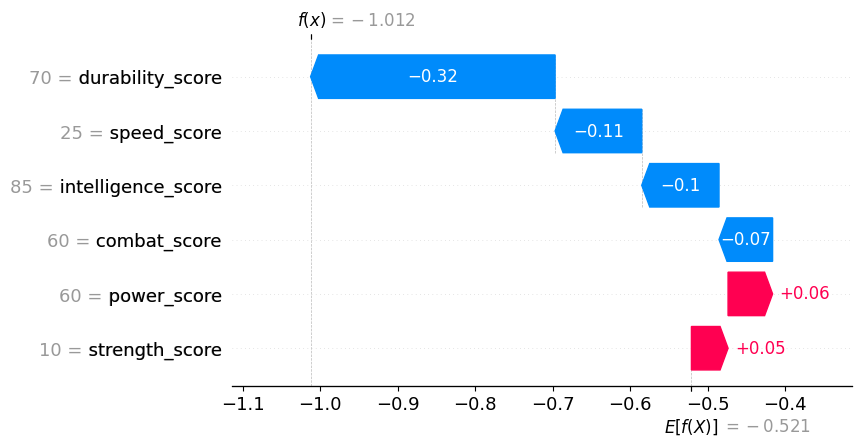

In [26]:
### Watrfall_plot
# Elegir una instancia cualquiera del conjunto de test
idx = 0

# Obtener base value correspondiente a la clase Good
if len(np.array(shap_exp.base_values).shape) == 2:
    base_value_good = shap_exp.base_values[idx, good_idx]
else:
    base_value_good = shap_exp.base_values[good_idx]

# Crear explicación individual para waterfall plot
waterfall_exp = shap.Explanation(
    values=shap_values_good[idx],
    base_values=base_value_good,
    data=X_test_num.iloc[idx].values,
    feature_names=NUMERICAL_FEATURES,
)

print("Instancia analizada:")
display(X_test_num.iloc[[idx]])

print("Clase real:", y_test.iloc[idx] if hasattr(y_test, "iloc") else y_test[idx])
print("Clase predicha:", lgbm_interp.predict(X_test_num.iloc[[idx]])[0])

# Waterfall plot para la clase Good
shap.plots.waterfall(waterfall_exp)

### 4.2.3 Pregunta de Cierre [0.2 Puntos]

1. ¿Qué diferencia existe entre Permutation Feature Importance y los SHAP values como medida de importancia de features?
2. Según el `waterfall_plot`, ¿qué features fueron las que más empujaron la predicción hacia su clase? Investiga el personaje seleccionado: ¿Tiene sentido dado su historia en los cómics?

> **Respuesta:**
La principal diferencia entre Permutation Feature Importance (PFI) y los SHAP values es que PFI es una medida global, evalúa cuánto empeora el rendimiento del modelo cuando se permuta una variable completa en el conjunto de datos. En cambio, SHAP entrega explicaciones locales, porque muestra cuánto aporta cada feature a una predicción individual, además nos dice, en qué dirección empuja la predicción y con qué magnitud.

> En el waterfall_plot de esta instancia, la predicción final fue "Bad". Como el gráfico está construido para la clase "Good", los SHAP values negativos son los que empujan la predicción lejos de "Good" y, por lo tanto, hacia "Bad". Las features que más empujaron en esa dirección fueron durability_score (-0.32), speed_score (-0.11), intelligence_score (-0.10) y combat_score (-0.07). En cambio, power_score (+0.06) y strength_score (+0.05) empujaron ligeramente hacia "Good", pero no alcanzaron a compensar el efecto de las demás variables.

> Por lo tanto, la variable más decisiva en este caso fue durability_score, seguida por speed_score e intelligence_score. Esto sugiere que, para esta observación, el modelo interpretó que ese perfil de atributos era más consistente con un personaje de alineación "Bad".  Esto tiene sentido considerando el contexto del personaje. Herman Schultz / The Shocker es descrito como un antiguo trabajador de salvamento y aparece asociado a una alineación "Bad". Aunque el modelo auxiliar no usa directamente el history_text, sino solo atributos numéricos, la predicción es coherente con la etiqueta del dataset y con la idea de que el personaje cumple un rol más cercano al antagonista que al héroe.

In [27]:
idx = 0
row_id = X_test_num.iloc[[idx]].index[0]

df_comics.loc[
    row_id,
    ["name", "real_name", "full_name", "alignment", "history_text"]
]

name                                            The Shocker (MCU)
real_name                                          Herman Schultz
full_name                                                     NaN
alignment                                                     Bad
history_text    Herman Schultz is a former salvage worker who ...
Name: 1303, dtype: object

---

# 5. Predicción de Personajes No Etiquetados [0.5 Puntos]

<p align="center">
  <img src="https://pbs.twimg.com/media/DolotxUUYAAbg7f.jpg" width="350">
</p>

¡Llegó el momento de predecir `Vergil`, `Gorilla Girl` y `Bat-Cow`!

Usaremos el **mejor modelo** obtenido en la sección 3 (`pipe_lgbm_opt`) para predecir la alineación de los personajes no etiquetados.

**Nota:** Recuerda eliminar los NaN en `history_text` antes de predecir.

### 5.0 Predicción [0.2 Puntos]

**To-do:**
- [ ] Usar `pipe_lgbm_opt` para predecir `alignment` en `df_comics_no_label` (recuerda eliminar NaN en `history_text`).
- [ ] Filtrar y mostrar resultados para `Vergil`, `Gorilla Girl` y `Bat-Cow`.

In [29]:
#### Código aquí ####

# Copia del dataset no etiquetado
df_no_label = df_comics_no_label.copy()

# Buscar los personajes en name, real_name y full_name
cols_busqueda = ["name", "real_name", "full_name"]

patron_personajes = r"Virgil|Gorilla Girl|Bat[- ]?Cow|Batcow"

mask_personajes = (
    df_no_label[cols_busqueda]
    .astype(str)
    .apply(lambda col: col.str.contains(patron_personajes, case=False, regex=True, na=False))
    .any(axis=1)
)

personajes_encontrados = df_no_label.loc[
    mask_personajes,
    ["name", "real_name", "full_name", "history_text"]
].copy()

personajes_encontrados["history_text_es_na"] = personajes_encontrados["history_text"].isna()

personajes_encontrados

,name,real_name,full_name,history_text,history_text_es_na
122,Batcow,NaN,NaN,Bat-Cow was originally a cow that was found by...,False
529,Gorilla Girl,Fahnbullah Eddy,Fahnbullah Eddy,A carnival performer with the ability to turn ...,False
122,Batcow,NaN,NaN,Bat-Cow was originally a cow that was found by...,False


In [30]:
# Eliminar NaN en history_text, como pide el enunciado
df_pred_targets = df_no_label.loc[mask_personajes].dropna(subset=["history_text"]).copy()

# Features para predicción
X_pred_targets = df_pred_targets[feature_cols].copy()

X_pred_targets["history_text"] = X_pred_targets["history_text"].fillna("")
X_pred_targets[numeric_features] = X_pred_targets[numeric_features].fillna(
    X_train[numeric_features].median()
)

# Predicción con el mejor modelo optimizado
df_pred_targets["alignment_pred"] = pipe_lgbm_opt.predict(X_pred_targets)

# Confianza
proba_targets = pipe_lgbm_opt.predict_proba(X_pred_targets)
df_pred_targets["confidence"] = proba_targets.max(axis=1)

# Mostrar resultados
resultados_finales = df_pred_targets[
    [
        "name",
        "real_name",
        "full_name",
        "alignment_pred",
        "confidence",
        "history_text",
    ]
]

resultados_finales

,name,real_name,full_name,alignment_pred,confidence,history_text
122,Batcow,NaN,NaN,Good,0.755835,Bat-Cow was originally a cow that was found by...
529,Gorilla Girl,Fahnbullah Eddy,Fahnbullah Eddy,Good,0.687981,A carnival performer with the ability to turn ...
122,Batcow,NaN,NaN,Good,0.755835,Bat-Cow was originally a cow that was found by...


In [33]:
pd.set_option("display.max_colwidth", None)
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 2000)

resultados_finales_limpios = (
    resultados_finales
    .drop_duplicates(subset=["name", "real_name", "full_name"])
    .reset_index(drop=True)
)

resultados_finales_limpios[
    [
        "name",
        "real_name",
        "full_name",
        "alignment_pred",
        "confidence",
        "history_text",
    ]
]

,name,real_name,full_name,alignment_pred,confidence,history_text
0,Batcow,NaN,NaN,Good,0.755835,"Bat-Cow was originally a cow that was found by Robin during an investigation on a slaughterhouse, which the cow was sent to. Robin wanted to keep the cow and named it Bat-Cow. Batman decided they would keep the cow. During a later investigation, Batman discovered it had mind-controlling radiation inside of it, leading him to attempt to get rid of the cow. Robin, however would not allow him to hurt the cow. After the events of Robin's death, Bat-Cow and Robin's dog felt a great loss in morale. Alfred Pennyworth and Nightwing had to take care of the cow. Later after Nightwing's disappearance, Alfred was the only caretaker of Bat-Cow. Bat-Cow, complete with cape, spent time on a Wayne Enterprises-owned dairy farm. It was there the cow encountered the cosmic-powered ""Forever People."" One of them seemed to gain guidance from Bat-Cow's actions, namely when Bat-Cow gave one of the Forever People a scarecrow's hat. Bat-Cow formed a friendship with Titus, a dog and household cat."
1,Gorilla Girl,Fahnbullah Eddy,Fahnbullah Eddy,Good,0.687981,"A carnival performer with the ability to turn into a gorilla, Fahnbullah Eddy and the rest of her fellow performers had their souls stolen by the magician Moondark and turned into his mindless slaves. The carnival was freed from Moondark by Spider-Man and Ghost Rider and their souls returned. Sometime after the incident with Moondark, Eddy and her fellow carnival performers Six and Muck briefly operated as a superhero team called the Freaks. In their only known outing as such, the team saved a doctor from being kidnapped by the villains Hammer and Anvil."


In [32]:
busqueda_virgil = df_comics_no_label.loc[
    df_comics_no_label.astype(str)
    .apply(lambda col: col.str.contains("Virgil|Hawkins|Static", case=False, regex=True, na=False))
    .any(axis=1),
    ["name", "real_name", "full_name", "history_text"]
]

busqueda_virgil

,name,real_name,full_name,history_text


Clase predicha por modelo auxiliar: Good


,intelligence_score,strength_score,speed_score,durability_score,power_score,combat_score
122,70,10,25,20,10,20


,feature,valor_feature,shap_value,abs_shap
0,intelligence_score,70,0.249095,0.249095
1,strength_score,10,0.130326,0.130326
4,power_score,10,-0.127920,0.127920
3,durability_score,20,0.052747,0.052747
5,combat_score,20,0.043603,0.043603
2,speed_score,25,0.019075,0.019075


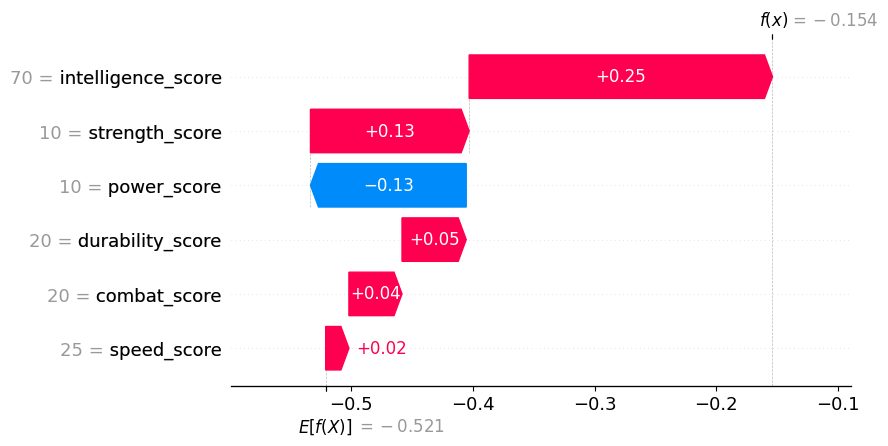

In [34]:
# Buscar Bat-Cow en el dataset no etiquetado
batcow_row = df_no_label.loc[
    df_no_label["name"].str.contains("Batcow|Bat-Cow|Bat Cow", case=False, regex=True, na=False)
].drop_duplicates(subset=["name", "real_name", "full_name"]).copy()

# Usar solo features numéricas para el modelo auxiliar de interpretabilidad
X_batcow_num = batcow_row[NUMERICAL_FEATURES].copy()

# Rellenar posibles NaN igual que en entrenamiento
X_batcow_num = X_batcow_num.fillna(X_train_num.median())

# Calcular SHAP values
shap_batcow = explainer(X_batcow_num)

# Clase predicha por el modelo auxiliar numérico
pred_batcow_interp = lgbm_interp.predict(X_batcow_num)[0]
class_idx = list(lgbm_interp.classes_).index(pred_batcow_interp)

print("Clase predicha por modelo auxiliar:", pred_batcow_interp)
display(X_batcow_num)

# Extraer valores SHAP para la clase predicha
if len(shap_batcow.values.shape) == 3:
    shap_values_batcow = shap_batcow.values[0, :, class_idx]
else:
    shap_values_batcow = shap_batcow.values[0]

if len(np.array(shap_batcow.base_values).shape) == 2:
    base_value_batcow = shap_batcow.base_values[0, class_idx]
else:
    base_value_batcow = shap_batcow.base_values[class_idx]

# Tabla ordenada de features que más influyen
shap_batcow_df = (
    pd.DataFrame({
        "feature": NUMERICAL_FEATURES,
        "valor_feature": X_batcow_num.iloc[0].values,
        "shap_value": shap_values_batcow,
        "abs_shap": np.abs(shap_values_batcow),
    })
    .sort_values("abs_shap", ascending=False)
)

display(shap_batcow_df)

# Waterfall plot para Bat-Cow
waterfall_batcow = shap.Explanation(
    values=shap_values_batcow,
    base_values=base_value_batcow,
    data=X_batcow_num.iloc[0].values,
    feature_names=NUMERICAL_FEATURES,
)

shap.plots.waterfall(waterfall_batcow)

### 5.1 Análisis de Predicciones [0.3 Puntos]

**Pregunta:** Comenta las predicciones obtenidas para `Vergil`, `Gorilla Girl` y `Bat-Cow`:

1. ¿Las predicciones te parecen razonables según lo que conoces (o puedes inferir) de estos personajes?
2. Conecta con la sección 4: ¿qué features numéricas habrían influido más en la predicción de **Bat-Cow** según el `waterfall_plot`? ¿Es consistente con la predicción obtenida aquí?

> **Respuesta:**
 El modelo predijo como "Good" tanto a Batcow como a Gorilla Girl. Batcow obtuvo una confianza aproximada de 0.756, mientras que Gorilla Girl obtuvo una confianza aproximada de 0.688. Esto indica que el modelo está más seguro de la clasificación de Batcow que de la de Gorilla Girl, aunque en ambos casos la clase predicha fue la misma.

> En el caso de Batcow, la predicción "Good" tiene bastante sentido según su historia. Batcow es originalmente una vaca encontrada por Robin durante una investigación. Luego Robin quiere quedarse con ella y Batman acepta cuidarla. La historia muestra que Batcow no actúa como antagonista, sino que queda asociada al entorno de Batman, Robin, Alfred y Nightwing. 

> En el caso de Gorilla Girl, la predicción "Good" también parece razonable. Su historia indica que era una artista de carnaval con la habilidad de transformarse en gorila. Ella y otros artistasfueron víctimas de Moondark, quien les robó sus almas y los convirtió en esclavos. Posteriormente, fueron liberados por Spider-Man y Ghost Rider. Además, Gorilla Girl formó parte de un equipo de superhéroes llamado Freaks y ayudó a salvar a un doctor que había sido secuestrado por villanos.

> Respecto a Virgil, no aparece en los resultados del dataset no etiquetado después de buscarlo por nombre directo y variantes como Virgil, Hawkins o Static. Por eso no fue posible generar una predicción para ese personaje con los datos disponibles.

> Conectando con la sección 4, el waterfall_plot de Bat-Cow muestra que las features numéricas que más empujaron la predicción fueron intelligence_score (+0.25) y strength_score (+0.13), seguidas por durability_score (+0.05), combat_score (+0.04) y speed_score (+0.02). La única variable que empujó en sentido contrario fue power_score (-0.13). En otras palabras, para el modelo auxiliar de interpretabilidad, la inteligencia fue el factor numérico más influyente en la clasificación de Bat-Cow. Esto es consistente con la predicción obtenida en la sección 5, donde Bat-Cow fue clasificado como "Good" con una confianza aproximada de 0.756. La mayoría de las features numéricas empujan en la misma dirección, y además la historia del personaje también es coherente con esa clase.


# Conclusión

¡Eso ha sido todo para el lab de hoy! Recuerden que el laboratorio tiene un plazo de entrega de una semana y que **los días de atraso no se pueden utilizar para entregas de lab, solo para tareas**. Cualquier duda del laboratorio, no duden en contactarnos por mail o U-cursos.

<p align="center">
  <img src="https://media1.tenor.com/images/fb5bf7cc5a4acb91b4177672886a88ba/tenor.gif?itemid=5591338">
</p>